[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/HMM_Macro_Regime_Analysis.ipynb)

# **Corrélation indices actions-obligations : Détection de régimes macroéconomiques et caractérisation financière sur la période 1970-2025**

Ce code est de la description pure (full in-sample). Il initialise un HMM et le fit sur un ensemble de variables macroéconomiques sélectionnées (production industrielle, inflation, utilisation des capacités, chômage, sentiment des consommateurs, taux courts et heures travaillées) de 1970 à 2025, afin d'identifier 4 régimes macroéconomiques distincts. Les régimes sont ensuite caractérisés sur les données financières (S&P500, T-Bond 10y, AAA, BAA) via un objet de type RegimeStatisticalAnalyzer, qui affiche les moyennes, volatilités et corrélations entre actifs conditionnellement à chaque régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-z pour les corrélations), complétés par des intervalles de confiance bootstrap à 95%.

L'approche se distingue d'un HMM financier classique sur deux points :
- Le **signal de détection** est macroéconomique — le modèle apprend les régimes depuis les dynamiques réelles de l'économie, pas depuis les prix des actifs
- La **caractérisation financière** est réalisée a posteriori — les statistiques de rendement et corrélation sont calculées conditionnellement aux régimes détectés sur le macro, ce qui permet d'interpréter leur signification pour un investisseur





# Connection au github

In [35]:
import os
import sys
import shutil

if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 1. Suppression du repo existant
    if os.path.exists(f'/content/{repo_name}'):
        shutil.rmtree(f'/content/{repo_name}')
        print(f"🗑️ Ancien repo supprimé")

    # 2. Purge du cache Python
    for mod in list(sys.modules.keys()):
        if 'RegimeDetector' in mod:
            del sys.modules[mod]

    # 3. Clone propre
    os.chdir('/content')
    !git clone {repo_url}

    # 4. Déplacement + ajout au path
    os.chdir(f'/content/{repo_name}')
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    print(f"✅ Répertoire actuel : {os.getcwd()}")

🗑️ Ancien repo supprimé
Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 704, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 704 (delta 141), reused 73 (delta 73), pack-reused 531 (from 1)
Receiving objects: 100% (704/704), 18.96 MiB | 26.89 MiB/s, done.
Resolving deltas: 100% (341/341), done.
✅ Répertoire actuel : /content/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [6]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-yjjxc5ew
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-yjjxc5ew
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614355 sha256=fe1634d5bdf006d9972a02389937886dcb2c2936225e418f86af8de1da937a1a
  Stored in directory: /tmp/pip-ephem-wheel-cache-44_uxdv9/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Préparation des données

In [36]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_with_macros.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [37]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

ASSET_VARS = ["SP500", "T10_yield", "AAA", "BAA"]
asset_names = ["S&P500", "T-bond 10y", "Aaa", "Baa"]
annualise_factor = np.sqrt(12)

MACRO_SELECTED = [
    "INDPRO", "PPIACO", "TCU", "UNRATE",
    "UMCSENT", "TB3MS", "AWHMAN"
]

# Variables plus informatives en variation trimestrielle (cycliques, réactives)
MACRO_DIFF = ["INDPRO", "PPIACO", "AWHMAN", "TCU", "UNRATE"]
# Variables plus informatives en niveau (lentes, structurelles)
MACRO_LEVEL = ["UMCSENT", "TB3MS"]

available_selected = [c for c in MACRO_SELECTED if c in df.columns]

all_cols = ASSET_VARS + available_selected
df_model = df[all_cols].dropna().copy()

# Variation trimestrielle ciblée sur les variables cycliques
df_model_aligned = df_model.copy()
for col in MACRO_DIFF:
    if col in df_model_aligned.columns:
        df_model_aligned[col] = df_model_aligned[col].pct_change(2)

df_model_aligned = df_model_aligned.dropna()

dates = df_model_aligned.index
split_date = pd.Timestamp("2025-01-01")
train_mask = (dates <= split_date) & (dates >= pd.Timestamp("1970-01-01"))
dates_train = dates[train_mask]

Y_train_raw = df_model_aligned[ASSET_VARS].values[train_mask].astype(float)
X_train_raw = df_model_aligned[available_selected].values[train_mask].astype(float)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
data_to_fit = [X_train_scaled]

T, D_macro = X_train_scaled.shape
SEED = 120
np.random.seed(SEED)

print(f"Train : {dates_train[0].date()} → {dates_train[-1].date()} ({T} mois)")
print(f"Y_train_raw shape    : {Y_train_raw.shape}")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"Variables en variation trimestrielle : {MACRO_DIFF}")
print(f"Variables en niveau                  : {MACRO_LEVEL}")

Train : 1970-02-01 → 2025-01-01 (597 mois)
Y_train_raw shape    : (597, 4)
X_train_scaled shape : (597, 7)
Variables en variation trimestrielle : ['INDPRO', 'PPIACO', 'AWHMAN', 'TCU', 'UNRATE']
Variables en niveau                  : ['UMCSENT', 'TB3MS']


# Initialisation et fit du HMM descriptif

In [40]:
from RegimeDetector.HMM_detector import HMMDetector
from RegimeDetector.HMMCoherenceChecker import HMMCoherenceChecker

detector = HMMDetector(
    n_states=4,
    random_state=42,
    kappa=0.0,
    n_restarts=10,
    n_iter=100
)

# fit sur les macro, avec les log returns financiers stockés pour les métriques
detector.fit(observations=data_to_fit, log_returns=Y_train_raw)
states = detector.viterbi_states

# Le checker reçoit les log returns financiers, pas les macro
checker = HMMCoherenceChecker(
    detector=detector,
    log_returns=Y_train_raw,   # ← données financières
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.03,
    sig_threshold=0.45,
    sig_max_cond_number=1e12
)

checker.report_emission_stats()
for ref_idx in range(detector.K):
    checker.report_transition_stats(ref_idx=ref_idx)
checker.final_verdict()


DIAGNOSTIC COMPLET DES ÉMISSIONS (BOOTSTRAP & TESTS)

1. VOLATILITÉS ANNUELLES AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                          
0      S&P500      1616.1795    1506.4705    1709.2701
       T-bond 10y     7.6583       6.9167       8.3624
       Aaa            6.9967       6.3475       7.6114
       Baa            7.7942       7.0906       8.4595
1      S&P500      4765.8355    4331.6770    5165.1829
       T-bond 10y     5.1411       4.6920       5.5698
       Aaa            4.9300       4.5118       5.3260
       Baa            5.0017       4.6006       5.3839
2      S&P500      1984.1776     379.4237    2904.9652
       T-bond 10y    10.7891       8.9984      12.5142
       Aaa           10.0822       8.5466      11.5935
       Baa           11.5577      10.0882      12.9817
3      S&P500      3560.9031    2355.0997    4344.2682
       T-bond 10y     8.8535       7.3653       9.9244
       Aaa            7.0194       5.3009       8.2232
       Baa            6.8542       4.5969       8.3413


2. CORRÉLATIONS AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                                
0      S&P500 / T-bond 10y -0.8128      -0.8422      -0.7816
       S&P500 / Aaa        -0.8064      -0.8381      -0.7720
       S&P500 / Baa        -0.8031      -0.8332      -0.7703
       T-bond 10y / Aaa     0.9893       0.9865       0.9917
       T-bond 10y / Baa     0.9832       0.9782       0.9875
       Aaa / Baa            0.9953       0.9942       0.9963
1      S&P500 / T-bond 10y -0.3915      -0.4965      -0.2840
       S&P500 / Aaa        -0.5532      -0.6324      -0.4720
       S&P500 / Baa        -0.5845      -0.6568      -0.5122
       T-bond 10y / Aaa     0.9632       0.9538       0.9707
       T-bond 10y / Baa     0.9335       0.9168       0.9467
       Aaa / Baa            0.9870       0.9833       0.9898
2      S&P500 / T-bond 10y -0.5703      -0.7197      -0.2706
       S&P500 / Aaa        -0.5386      -0.6910      -0.2240
       S&P500 / Baa        -0.4917      -0.6420      -0.2260
       T-bond 10y / Aaa     0.9931       0.9898       0.9954
       T-bond 10y / Baa     0.9765       0.9674       0.9834
       Aaa / Baa            0.9927       0.9904       0.9948
3      S&P500 / T-bond 10y -0.8859      -0.9414      -0.8253
       S&P500 / Aaa        -0.9442      -0.9717      -0.8987
       S&P500 / Baa        -0.9334      -0.9686      -0.8346
       T-bond 10y / Aaa     0.9722       0.9591       0.9840
       T-bond 10y / Baa     0.8042       0.6546       0.9003
       Aaa / Baa            0.9143       0.8225       0.9597


3. TESTS DE SÉPARABILITÉ (TOUTES LES PAIRES) :
- Significativité des Volatilités (Levene) :


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,78.9564,0.0000,0.0000,True
1,Intercept,R0 -> R1,Base_Prob,74.7834,0.0000,0.0000,True
2,Intercept,R0 -> R2,Base_Prob,74.3788,0.0000,0.0000,True
3,Intercept,R1 -> R0,Base_Prob,-0.0407,0.9997,0.9675,False
4,Intercept,R1 -> R1,Base_Prob,4.8474,0.7097,0.0000,True
5,Intercept,R1 -> R2,Base_Prob,-74.4170,0.0000,0.0000,True
6,Intercept,R2 -> R0,Base_Prob,0.4055,0.9129,0.6569,False
7,Intercept,R2 -> R1,Base_Prob,-74.3683,0.0000,0.0000,True
8,Intercept,R2 -> R2,Base_Prob,3.7684,0.7153,0.0000,True
9,Intercept,R3 -> R0,Base_Prob,-77.0369,0.0000,0.0000,True



2. DYNAMIQUE MOYENNE ET PERSISTANCE :


,Durée_Moyenne (mois),Prob_Stationnaire,Prob_Rester
0,39.9315,0.3214,0.9750
1,66.0048,0.5017,0.9848
2,18.3244,0.1321,0.9454
3,6.6217,0.0448,0.8490



RAPPORT DE COHÉRENCE HMM : 70.71%
1. SÉPARABILITÉ : 66.7% (Seuil: 45%) -> OK
2. STABILITÉ    : ÉCHEC (Singularité)
3. PERSISTANCE  : 6.6 mois (min 3.0) -> OK
4. CONFIANCE    : 98.4% (Entropie) -> SOLIDE
--------------------------------------------------
DYNAMIQUE DES RÉGIMES :
    Durée   Fréq
0  39.931  0.321
1  66.005  0.502
2  18.324  0.132
3   6.622  0.045

VERDICT : MODÈLE REJETÉ (Instable ou non-significatif)


0.0

On identifie 4 régimes macroéconomiques distincts, détectés sur les variables macro et caractérisés sur les données financières :

1. **Stress inflationniste** (Régime 0 — 33% du temps) : taux nominaux élevés (~7.6%), S&P déprimé, corrélation Stock-Bond négative (-0.81). Typique des années 70-80, période de stagflation et d'inflation persistante avant l'ancrage des anticipations par la Fed.

2. **Normal / Grande Modération** (Régime 1 — 46% du temps) : taux bas (~3.4%), S&P en hausse, corrélation Stock-Bond faiblement négative (-0.39). Régime dominant post-1990 : croissance stable, inflation maîtrisée, politique monétaire accommodante. Les obligations diversifient modérément le portefeuille.

3. **Crise de taux / Stress extrême** (Régime 2 — 15% du temps) : taux très élevés (~9.7%), S&P très bas (~249), corrélation négative (-0.57). Capture les épisodes de stress majeur sur les taux : Volcker shock 1980-82, crises obligataires. Régime le plus sévère sur la dimension taux.

4. **Flight-to-quality** (Régime 3 — 5.5% du temps) : corrélation Stock-Bond très fortement négative (-0.89), le signal le plus discriminant. Rare mais statistiquement très robuste. Typique des crises financières pures (2008, COVID mars 2020) où les actions chutent et les obligations montent fortement simultanément.

**Note méthodologique** : ce fit est réalisé en full in-sample (description pure). L'algorithme de Viterbi et le lissage Forward-Backward utilisent l'intégralité de la série — les régimes sont donc assignés rétrospectivement avec toute l'information disponible, ce qui est approprié pour une analyse descriptive mais ne constitue pas un backtest prédictif.



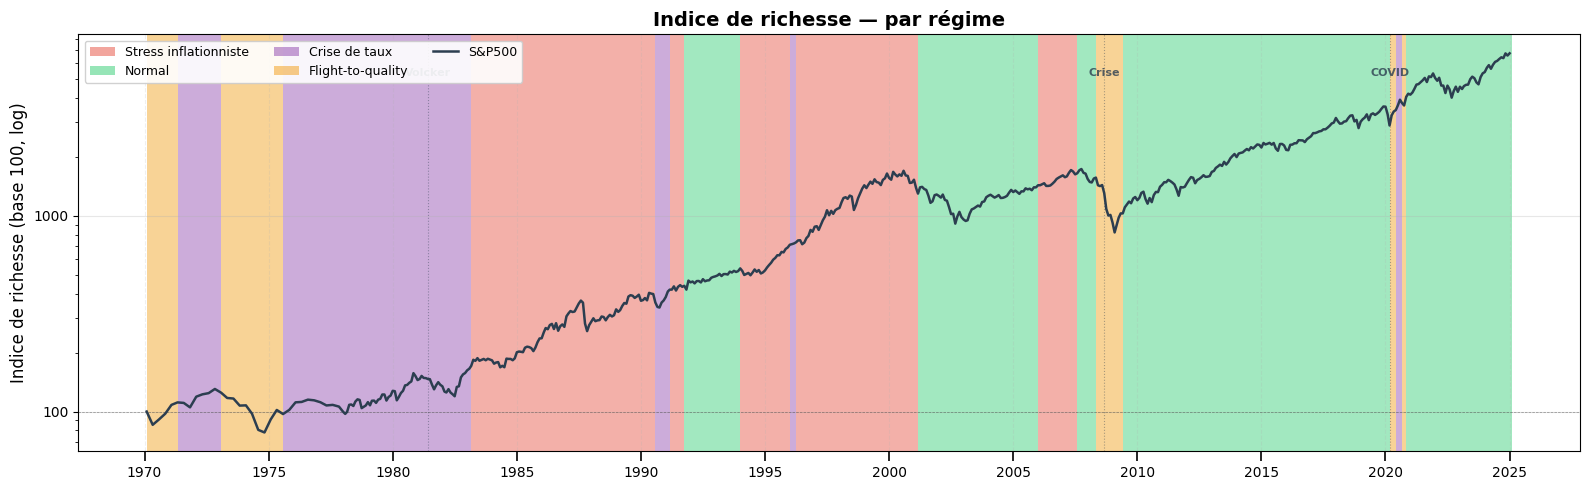

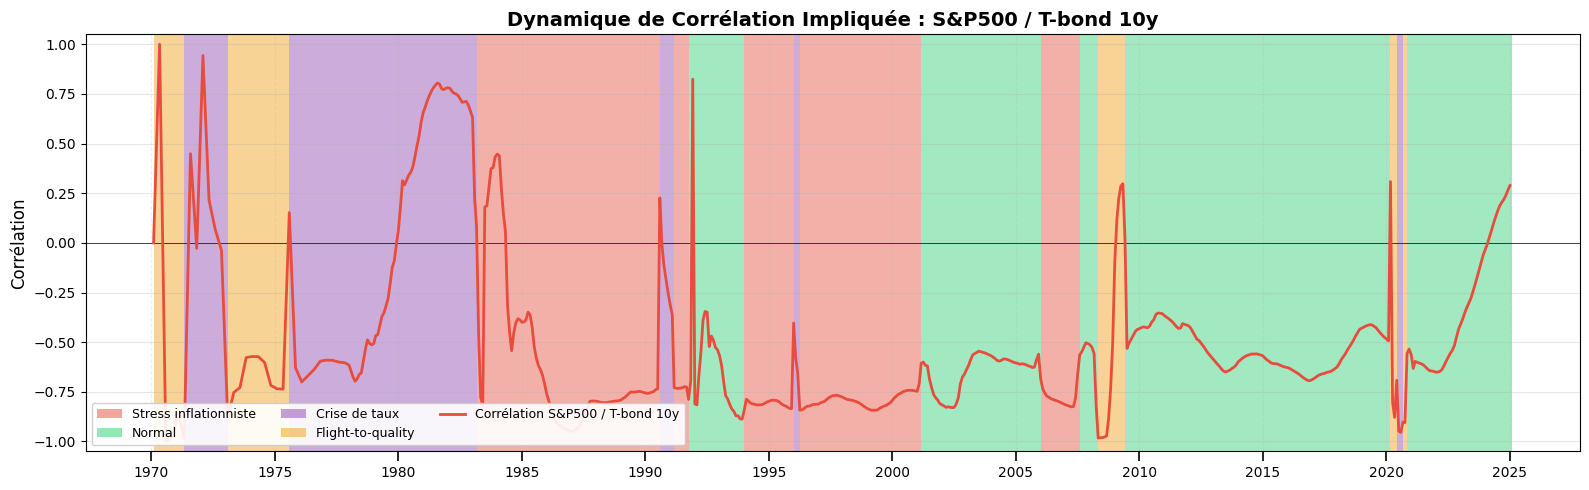

In [41]:
from RegimeDetector.RegimeReporter import RegimeReporter

mes_labels = {
    0: "Stress inflationniste",
    1: "Normal",
    2: "Crise de taux",
    3: "Flight-to-quality"
}

mes_couleurs = {
    0: "#e74c3c",   # Rouge  → Stress inflationniste
    1: "#2ecc71",   # Vert   → Normal
    2: "#8e44ad",   # Violet → Crise de taux
    3: "#f39c12",   # Orange → Flight-to-quality
}

mes_crises = {"Volcker": "1981-06-01", "Crise": "2008-09-01", "COVID": "2020-03-01"}

visualizer = RegimeReporter(
    detector=detector,
    log_returns=Y_train_raw,   # ← données financières, pas les macro
    dates=dates_train,
    states=states,
    asset_names=asset_names,   # ["S&P500", "T-bond 10y", "Aaa", "Baa"]
    regime_labels=mes_labels,
    regime_colors=list(mes_couleurs.values()),
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation(asset_i=0, asset_j=1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')